In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
transcript_info = pd.read_csv(
    "BECancerResistome/data/TranscriptInfoBiomartExport17122024.txt.gz", sep="\t"
)
transcript_length = transcript_info.groupby("Transcript stable ID version")[
    "Transcript length (including UTRs and CDS)"
].first()

/var/folders/5v/3w39hhps0k15qx5v_t82tpvh0000gn/T/ipykernel_21233/585090872.py:1: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  transcript_info = pd.read_csv(


## Import Coelho et at. dataset


In [4]:
be_coelho = pd.read_excel(
    "data/41588_2024_1948_MOESM4_ESM.xlsx", sheet_name="ST2 BE z-scores"
)

In [5]:
be_coelho = be_coelho.set_index(["guide", "editor"])[
    [c for c in be_coelho if "average_zscore" in c]
]
be_coelho.sample(15)

,,L2FC_HT29_DebCet_plasmid_average_zscore,L2FC_HT29_Tram_plasmid_average_zscore,L2FC_HT29_Pict_plasmid_average_zscore,L2FC_HT29_Control_plasmid_average_zscore,L2FC_H23_Adag_plasmid_average_zscore,L2FC_H23_Sotor_plasmid_average_zscore,L2FC_H23_Control_plasmid_average_zscore,L2FC_PC9_Control_plasmid_average_zscore,L2FC_PC9_Osim_plasmid_average_zscore,L2FC_PC9_Gefit_plasmid_average_zscore,L2FC_MHHES1_Olap_plasmid_average_zscore,L2FC_MHHES1_Nirap_plasmid_average_zscore,L2FC_MHHES1_Control_plasmid_average_zscore
guide,editor,,,,,,,,,,,,,
CAGCCGTATTTCTACTGCGA,CBE,-1.551326,-0.945318,-1.208338,-0.841034,-1.117139,-0.163077,-0.919747,-0.847267,-0.130302,-0.229618,NaN,NaN,NaN
GCTTGCATTGATAGAAATGG,ABE,-0.066286,0.033245,-0.043968,-0.456703,-0.017308,0.237763,-0.210030,-0.675271,-0.566343,-0.157346,-0.594972,-0.930142,-0.663862
CCTAAGCCCCTGGTGACAGA,CBE,1.003993,0.723163,0.722046,0.957063,0.531872,1.028056,1.107534,1.198214,0.912815,0.565889,NaN,NaN,NaN
TCGGATAGCCCCGCCTGAAG,CBE,0.674465,0.487291,0.856352,0.910718,0.872875,0.944919,1.408129,0.463637,0.189481,0.059953,NaN,NaN,NaN
GCTACTCATCTTCAACAAGC,ABE,1.034110,0.584694,0.691951,0.698707,2.700465,-0.036576,-0.336702,0.543766,0.623211,0.623466,1.812175,1.795183,0.916931
CCATCACACCACCTGACCAA,CBE,0.924586,0.557300,0.779542,-0.068492,-0.273827,-0.795097,0.148760,0.581742,0.582224,0.427417,NaN,NaN,NaN
TCGACTCGATAGAGCTTATC,CBE,-1.801371,-1.347080,-1.033448,-1.952116,-2.195032,-1.505419,-2.167148,-2.506400,-1.458815,-2.000858,NaN,NaN,NaN
AAGCTCAAAACTGACATTAA,ABE,0.924909,0.272350,0.418461,0.415734,0.501485,-0.629155,0.493057,0.447354,0.327771,0.333736,-0.001367,-0.166633,-0.222004
GCGGGGGGCGGAGGCTGCTG,ABE,0.361617,-0.370247,-1.109668,-1.046031,0.054264,-0.644503,-0.645174,-0.819549,-0.399885,-0.008366,-2.463886,-2.201650,-1.067659


## Import sgRNA Beagle Library


In [7]:
variants_beagle = pd.read_csv(f"data/BeagleCoelho/EG_collab-guides-HGVS.txt", sep="\t")
variants_beagle.sample(15)

,Input,CRISPR Enzyme,Edit Type,Edit Window,Target Taxon,Target Assembly,Target Genome Sequence,Target Gene ID,Target Gene Symbol,Target Gene Strand,...,sgRNA Orientation,Nucleotide Edits (global),Guide Edits,Nucleotide Edits,Amino Acid Edits,Mutation Category,Constraint Violations,Note,editor,hgvs
3570,ENST00000263967.4,SpyoCas9NG,A-G,4..8,9606,GRCh38,NC_000003.12,ENSG00000121879,PIK3CA,+,...,antisense,179219692T>C,A_8,1868T>C,Leu623Ser,Missense,poly(T):TTTTT,NaN,ABE,['ENST00000263967.4:c.1868T>C']
13420,ENST00000366794.10,SpyoCas9NG,A-G,4..8,9606,GRCh38,NC_000001.11,ENSG00000143799,PARP1,-,...,sense,226367494T>C;226367493T>C,A_7;A_8,2392A>G;2393A>G,Lys798Gly,Missense,NaN,NaN,ABE,['ENST00000366794.10:c.2392A>G;2393A>G']
3713,ENST00000263967.4,SpyoCas9NG,C-T,4..8,9606,GRCh38,NC_000003.12,ENSG00000121879,PIK3CA,+,...,antisense,179221023G>A;179221024G>A,C_5;C_4,2053G>A;2054G>A,Gly685Asn,Missense,NaN,NaN,CBE,['ENST00000263967.4:c.2053G>A;2054G>A']
12514,ENST00000333681.5,SpyoCas9NG,A-G,4..8,9606,GRCh38,NC_000018.10,ENSG00000171791,BCL2,-,...,sense,63318593T>C,A_7,74A>G,Gln25Arg,Missense,NaN,NaN,ABE,['ENST00000333681.5:c.74A>G']
2442,ENST00000263967.4,SpyoCas9NG,A-G,4..8,9606,GRCh38,NC_000003.12,ENSG00000121879,PIK3CA,+,...,antisense,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ABE,-
347,ENST00000262948.10,SpyoCas9NG,C-T,4..8,9606,GRCh38,NC_000019.10,ENSG00000126934,MAP2K2,-,...,sense,4095437G>A,C_8,997C>T,Leu333Leu,Silent,NaN,NaN,CBE,['ENST00000262948.10:c.997C>T']
17421,ENST00000429687.8,SpyoCas9NG,C-T,4..8,9606,GRCh38,NC_000014.9,ENSG00000129484,PARP2,+,...,antisense,"20354903G>A, 20354904G>A","C_5, C_4","858G>A, 859G>A","Met286Ile, Glu287Lys","Missense, Missense",NaN,NaN,CBE,"['ENST00000429687.8:c.858G>A', 'ENST0000042968..."
3431,ENST00000263967.4,SpyoCas9NG,C-T,4..8,9606,GRCh38,NC_000003.12,ENSG00000121879,PIK3CA,+,...,antisense,179219253G>A,C_8,1722G>A,Trp574Ter,Nonsense,NaN,NaN,CBE,['ENST00000263967.4:c.1722G>A']
16942,ENST00000429687.8,SpyoCas9NG,A-G,4..8,9606,GRCh38,NC_000014.9,ENSG00000129484,PARP2,+,...,sense,"20350573A>G, 20350575A>G;20350576A>G","A_5, A_7;A_8","372A>G, 374A>G;375A>G","Leu124Leu, Glu125Gly","Silent, Missense",NaN,NaN,ABE,"['ENST00000429687.8:c.372A>G', 'ENST0000042968..."
16987,ENST00000429687.8,SpyoCas9NG,C-T,4..8,9606,GRCh38,NC_000014.9,ENSG00000129484,PARP2,+,...,sense,NaN,NaN,NaN,NaN,NaN,poly(T):TTTTT,NaN,CBE,-


## Import Variants VEP


In [8]:
variants_vep = pd.read_csv(
    f"data/BeagleCoelho/EG_collab-guides-VEP-HGVS-output.txt", sep="\t"
)
variants_vep.shape

/var/folders/5v/3w39hhps0k15qx5v_t82tpvh0000gn/T/ipykernel_21233/3279890295.py:1: DtypeWarning: Columns (23,84,85,86,87,88,89,90,91,107) have mixed types. Specify dtype option on import or set low_memory=False.
  variants_vep = pd.read_csv(


(68764, 117)

In [9]:
variants_vep = variants_vep.query("MANE == 'MANE_Select'")
variants_vep.shape

(26484, 117)

In [10]:
variants_vep["editor"] = (
    variants_vep["UPLOADED_ALLELE"]
    .apply(lambda v: "ABE" if v in {"G/A", "A/G"} else "CBE")
    .values
)

#### Number of guides per gene


In [11]:
plot_df = (
    variants_vep.groupby(["Feature", "SYMBOL"])["#Uploaded_variation"]
    .count()
    .sort_values(ascending=False)
).reset_index()
plot_df["Transcript length"] = plot_df["Feature"].map(transcript_length)

Text(0, 0.5, 'Gene')

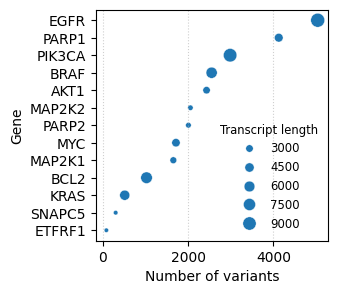

In [12]:
_, ax = plt.subplots(figsize=(3, 3))

sns.scatterplot(
    data=plot_df,
    x="#Uploaded_variation",
    y="SYMBOL",
    size="Transcript length",
    sizes=(10, 100),
    ax=ax,
)

handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles=handles[1:],
    labels=labels[1:],
    title="Transcript length",
    title_fontsize="small",
    fontsize="small",
    frameon=False,
)

ax.grid(axis="x", linestyle=":", alpha=0.6)

ax.set_xlabel("Number of variants")
ax.set_ylabel("Gene")

## Protein variants


In [ ]:
def classify_aminoacid_change(row):
    if row["Amino_acids"] == "-":
        return "Frameshift"

In [47]:
variants_vep["Amino_acids"]

0        -
2        -
4        -
6        -
8        -
        ..
68745    -
68749    -
68753    -
68757    -
68761    -
Name: Amino_acids, Length: 26484, dtype: object